<font color='blue'> **2a _______________ One-Dimensional Steady Conduction with Dirichlet Boundary Conditions _______________** </font> 

In [1]:
from Grid import Grid  ; from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc        ;from ScalarCoeffs import ScalarCoeffs   
import numpy as np ;from numpy.linalg import norm  ;import matplotlib.pyplot as plt ;from Models import DiffusionModel, SurfaceConvectionModel ; from LinearSolver import solve  

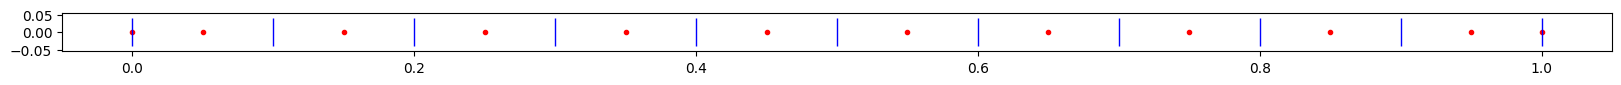

In [2]:
fig, ax = plt.subplots(figsize=(20, 0.5))                                    ; lx=1.0 ;ly=0.1 ;lz=0.1 ;ncv=10 ; grid = Grid(lx, ly, lz, ncv)                    # centroid | faces
ax.plot  (grid.xP, np.zeros_like(grid.xP), 'o',markersize=3,color='red')     ; ax.plot  (grid.xf, np.zeros_like(grid.xf), '|', markersize=20,color='b')      ; plt.show()

In [3]:
T0 = 300   ; T = T0*np.ones(grid.ncv+2)   ; T_solns = [np.copy(T)]     ; print('T',len(T),T)      ;maxIter = 100  ;coeffs = ScalarCoeffs(grid.ncv) ;converged = 1e-15
#______________init__(self,phi ,grid ,value ,loc) _________________________________________________________________________________________________________________
west_bc = DirichletBc(     T   ,grid ,1000   ,BoundaryLocation.WEST)    ; west_bc.apply()         ;east_bc = DirichletBc(T,grid,-30,BoundaryLocation.EAST)  ; east_bc.apply()  
# k = thermophysical properties ... conductivity!!  T = temp !!          
# BC    if self._loc is BoundaryLocation.WEST:      self._phi[0] = self._value     #elif self._loc is BoundaryLocation.EAST:    self._phi[-1] = self._value

T 12 [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]


<font color='blue'> **Linearization ____ PDE ____** </font> 
$ 
\quad\quad\quad      L(\phi^*) = 0 
\quad\quad\quad      \mathbf{r}(\phi_i)     + \left.\frac{\partial\mathbf{r}}{\partial\phi}\right|_{\phi_i}           \left(\phi - \phi_i \right)         = 0
$ <font color='blue'> 
$   \quad\quad\quad      \mathbf{J}(\phi)    = \frac{\partial\mathbf{r}}{\partial\phi}$
$   \quad\quad\quad      \Delta\phi=\left(\phi - \phi_i \right)$
</font> 
$
\quad\quad\quad      \mathbf{J}\left(\phi_i\right)       \Delta\phi      = - \mathbf{r}(\phi_i)
\quad\quad\quad      \phi = \phi_i + \Delta\phi_i 
$

In [ ]:
# ____________________init__(self, grid ,phi ,gamma,west_bc ,east_bc):   ___________________________________________________________________________________________
k=0.1;  diffusion = DiffusionModel(grid ,T   ,k    ,west_bc ,east_bc)        
for i in range(maxIter):
    coeffs.zero()             ; coeffs = diffusion.add(coeffs)   ;maxResid = norm(coeffs.rP, np.inf)      ;avgResid    = np.mean(np.absolute(coeffs.rP))
    print("Iteration = {}                                        ;Max.Resid. = {}                         ;Avg. Resid. = {}".format(i, maxResid, avgResid))
    if maxResid < converged:    break
    dT = solve(coeffs)        ;T[1:-1] += dT                     ;west_bc.apply();east_bc.apply();T_solns.append(np.copy(T))       # Difusion flux_w=-k*grid.Aw*(T[1:-1]-T[0:-2])/grid.dx_WP

Iteration = 0                                        ;Max.Resid. = 14.000000000000004                         ;Avg. Resid. = 2.0599999999999996
Iteration = 1                                        ;Max.Resid. = 1.5543122344752192e-15                         ;Avg. Resid. = 4.884981308350689e-16
Iteration = 2                                        ;Max.Resid. = 6.661338147750939e-16                         ;Avg. Resid. = 2.6645352591003756e-16


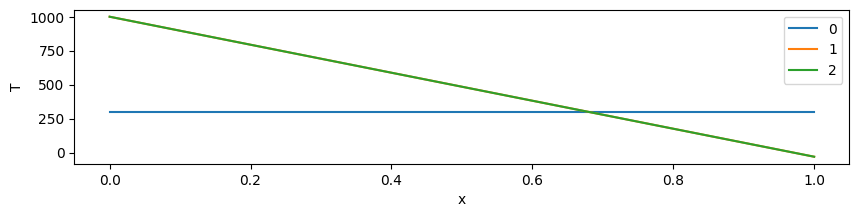

In [5]:
fig = plt.figure(figsize=(10, 2))                           ; i = 0
for T in T_solns:     plt.plot(grid.xP, T, label=str(i))    ; i += 1
plt.xlabel("x")     ; plt.ylabel("T")        ; plt.legend() ; plt.show()   # ; print(T_solns[0],T_solns[1])

In [6]:
print(grid.xf)    ; print(grid.xP)                        # Face   # Centroids
print(grid.Af)    ; print(grid.Ao)    ; print(grid.vol)   ; print(T_solns[0]) ; print(T_solns[1])                     
print(grid.dx_WP)   ; print(grid.dx_PE) ; print(grid.Aw)    ; print(grid.Ae)        # Areas  # outer surface area  ;# VOL  # RES

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[0.   0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95 1.  ]
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
[0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]
[300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
[1000.   948.5  845.5  742.5  639.5  536.5  433.5  330.5  227.5  124.5
   21.5  -30. ]
[0.05 0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1 ]
[0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.05]
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


$$
\quad\quad\quad      \int_V \phi dV \approx \left[\phi_P + O(\delta^2)\right] V_P  

$$